<a href="https://colab.research.google.com/github/MamidiPravallikaReddy/DL_LAB/blob/main/DL_week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement CNN on MNITST Dataset

In [2]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten

from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test /= 255

n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

model = Sequential()
model.add(Conv2D(25, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu', input_shape=(28,28,1)))



model.add(MaxPool2D(pool_size=(1,1)))

model.add(Flatten())
model.add(Dense(100, activation='relu'))

model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))







11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape before one-hot encoding:  (60000,)
Shape after one-hot encoding:  (60000, 10)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 102ms/step - accuracy: 0.9440 - loss: 0.1921 - val_accuracy: 0.9754 - val_loss: 0.0781
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 93s 125ms/step - accuracy: 0.9822 - loss: 0.0604 - val_accuracy: 0.9813 - val_loss: 0.0567
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 98ms/step - accuracy: 0.9894 - loss: 0.0345 - val_accuracy: 0.9824 - val_loss: 0.0543
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 93ms/step - accuracy: 0.9938 - loss: 0.0208 - val_accuracy: 0.9827 - val_loss: 0.0547
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 94ms/step - accuracy: 0.9958 - loss: 0.0143 - val_accuracy: 0.9834 - val_loss: 0.0556
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 94ms/step - accuracy: 0.9973 - loss: 0.0092 - val_accuracy: 0.9825 - val_loss: 0.0590
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9982 - loss: 0.0069 - val_accuracy: 0.9839 - val_loss: 0.0530
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9984 - loss: 0.0058 

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

In [4]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)


In [5]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.8039 - loss: 0.5344 - val_accuracy: 0.8552 - val_loss: 0.4010
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 35ms/step - accuracy: 0.8762 - loss: 0.3421 - val_accuracy: 0.8814 - val_loss: 0.3222
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 36ms/step - accuracy: 0.8933 - loss: 0.2915 - val_accuracy: 0.8953 - val_loss: 0.2967
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.9037 - loss: 0.2597 - val_accuracy: 0.8930 - val_loss: 0.2881
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 34ms/step - accuracy: 0.9117 - loss: 0.2363 - val_accuracy: 0.8898 - val_loss: 0.2979
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9195 - loss: 0.2149 - val_accuracy: 0.9001 - val_loss: 0.2709
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9270 - loss: 0.1976 - val_accuracy: 0.9043 - val_loss: 0.2678
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9319 -

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9017 - loss: 0.2839
Test Accuracy: 0.9017000198364258


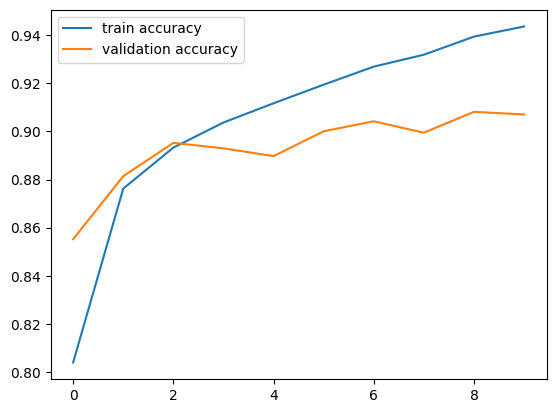

In [9]:
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.legend()
plt.show()

In [10]:
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.7749 - loss: 0.6194 - val_accuracy: 0.8524 - val_loss: 0.3937
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.8615 - loss: 0.3862 - val_accuracy: 0.8856 - val_loss: 0.3151
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.8843 - loss: 0.3240 - val_accuracy: 0.8854 - val_loss: 0.3107
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 38ms/step - accuracy: 0.8977 - loss: 0.2875 - val_accuracy: 0.8897 - val_loss: 0.3025
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9041 - loss: 0.2626 - val_accuracy: 0.9039 - val_loss: 0.2598
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.9130 - loss: 0.2405 - val_accuracy: 0.8978 - val_loss: 0.2712
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9183 - loss: 0.2224 - val_accuracy: 0.9020 - val_loss: 0.2608
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 37ms/step - accuracy: 0.9234 -

In [13]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9049 - loss: 0.2797


[0.2797187864780426, 0.9049000144004822]